# Layer 2 (Rebuilt): Progress Export + 2017-2019 S2 + Temporal Classifier

This notebook uses `data/progress_export.xlsx` as the Layer-2 dataset, augments it with 2017-2019 Sentinel-2 features from `data/ghana_parquet`, engineers temporal trend features (2017-2023 where available), and trains classifiers.

Targets from `poor_condition_class`:
- Multiclass: `low / medium / high`
- Binary high-risk: `high` vs `not_high`


In [13]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    f1_score,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 300)

RANDOM_STATE = 42


In [14]:
# Load progress export (new Layer-2 source)
DATA_PATH = Path('../data/progress_export.xlsx')
SHEET = 'manual validation'

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Missing file: {DATA_PATH.resolve()}')

df = pd.read_excel(DATA_PATH, sheet_name=SHEET)
print('Rows:', len(df), 'Cols:', len(df.columns))
print('Target distribution:')
print(df['poor_condition_class'].astype(str).str.strip().str.lower().value_counts(dropna=False))


Rows: 800 Cols: 95
Target distribution:
poor_condition_class
medium    422
low       317
high       61
Name: count, dtype: int64


In [15]:
# Standardize keys and target columns
base = df.copy()
base['osm_id'] = base['osm_id'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
base['poor_condition_class'] = base['poor_condition_class'].astype(str).str.strip().str.lower()

# Keep expected classes only
base = base[base['poor_condition_class'].isin(['low','medium','high'])].copy()
base['is_high_risk'] = (base['poor_condition_class'] == 'high').astype(int)

print('Usable rows:', len(base))
print(base['poor_condition_class'].value_counts())


Usable rows: 800
poor_condition_class
medium    422
low       317
high       61
Name: count, dtype: int64


In [16]:
# Detect existing 2020-2023 S2 columns already present in progress_export
s2_pattern = re.compile(r'^(ndvi|ndmi|ndbi|ndwi|bsi)_(\d{4})_Q([1-4])$')
existing_s2_cols = [c for c in base.columns if s2_pattern.match(str(c))]
print('Existing S2 columns in export:', len(existing_s2_cols))
print('Sample:', existing_s2_cols[:10])


Existing S2 columns in export: 80
Sample: ['ndvi_2020_Q1', 'ndvi_2020_Q2', 'ndvi_2020_Q3', 'ndvi_2020_Q4', 'ndvi_2021_Q1', 'ndvi_2021_Q2', 'ndvi_2021_Q3', 'ndvi_2021_Q4', 'ndvi_2022_Q1', 'ndvi_2022_Q2']


In [17]:
# Load 2017-2019 from ghana_parquet robustly (skip unreadable parquet files)
PARQ_ROOT = Path('../data/ghana_parquet')
YEARS_EXT = [2017, 2018, 2019]
idx_cols = ['NDVI','NDMI','NDBI','NDWI','BSI']

frames = []
read_log = []

for y in YEARS_EXT:
    year_dir = PARQ_ROOT / f'year={y}'
    files = sorted(year_dir.glob('*.parquet')) if year_dir.exists() else []
    if not files:
        read_log.append((y, 0, 0, 'no_files'))
        continue

    ok, bad = 0, 0
    year_frames = []
    for f in files:
        try:
            t = pd.read_parquet(f)
            year_frames.append(t)
            ok += 1
        except Exception:
            bad += 1

    if year_frames:
        yf = pd.concat(year_frames, ignore_index=True)

        # force year from partition folder (works even if parquet has no year column)
        yf['year'] = y

        # only require non-partition columns from file
        need_no_year = ['osm_id', 'quarter', *idx_cols]
        miss = [c for c in need_no_year if c not in yf.columns]
        if miss:
            print(f"Skipping year {y}: missing columns {miss}")
        else:
            yf = yf[need_no_year + ['year']].copy()
            frames.append(yf)

    read_log.append((y, ok, bad, 'ok' if ok > 0 else 'all_failed'))

print('Read log (year, files_ok, files_bad, status):')
for row in read_log:
    print(row)

if frames:
    ext = pd.concat(frames, ignore_index=True)
    ext['osm_id'] = ext['osm_id'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
    ext['quarter'] = ext['quarter'].astype(str).str.upper().str.strip()
    for c in idx_cols:
        ext[c] = pd.to_numeric(ext[c], errors='coerce')

    ext = ext.groupby(['osm_id','year','quarter'], as_index=False)[idx_cols].mean()

    long = ext.melt(
        id_vars=['osm_id','year','quarter'],
        value_vars=idx_cols,
        var_name='index_name',
        value_name='value'
    )
    long['index_name'] = long['index_name'].str.lower()
    long['col'] = long['index_name'] + '_' + long['year'].astype(str) + '_' + long['quarter']

    ext_wide = long.pivot_table(index='osm_id', columns='col', values='value', aggfunc='mean').reset_index()
    ext_wide.columns.name = None
    print('2017-2019 wide rows:', len(ext_wide), 'cols:', len(ext_wide.columns))
else:
    ext_wide = pd.DataFrame({'osm_id': base['osm_id'].drop_duplicates()})
    print('Warning: no 2017-2019 parquet files could be loaded in this environment.')


Read log (year, files_ok, files_bad, status):
(2017, 1, 0, 'ok')
(2018, 1, 0, 'ok')
(2019, 1, 0, 'ok')
2017-2019 wide rows: 326546 cols: 46


In [18]:
# Merge 2017-2019 extension into base dataset
work = base.merge(ext_wide, on='osm_id', how='left')

# Build final S2 column list (2017-2023 where available)
all_s2_cols = [c for c in work.columns if s2_pattern.match(str(c))]
all_s2_cols = sorted(all_s2_cols)

print('Merged rows:', len(work))
print('Total S2 columns after merge:', len(all_s2_cols))
print('S2 years present:', sorted({int(s2_pattern.match(c).group(2)) for c in all_s2_cols}))


Merged rows: 800
Total S2 columns after merge: 125
S2 years present: [2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [21]:
# Temporal feature engineering across available years/quarters (2017-2023 when present)

def ordered_cols_for_index(columns, idx_name):
    parsed = []
    for c in columns:
        m = s2_pattern.match(c)
        if m and m.group(1) == idx_name:
            parsed.append((int(m.group(2)), int(m.group(3)), c))
    parsed.sort(key=lambda x: (x[0], x[1]))
    return [c for _, _, c in parsed]


def row_slope(vals):
    vals = np.array(vals, dtype=float)
    mask = ~np.isnan(vals)
    if mask.sum() < 4:
        return np.nan
    x = np.arange(len(vals))[mask]
    y = vals[mask]
    return float(np.polyfit(x, y, 1)[0])

idx_names = sorted({s2_pattern.match(c).group(1) for c in all_s2_cols})

temporal = pd.DataFrame(index=work.index)
for idx in idx_names:
    cols = ordered_cols_for_index(all_s2_cols, idx)
    m = work[cols].apply(pd.to_numeric, errors='coerce')

    temporal[f'{idx}_mean_all'] = m.mean(axis=1)
    temporal[f'{idx}_std_all'] = m.std(axis=1)
    temporal[f'{idx}_qoq_mean_change'] = m.diff(axis=1).mean(axis=1)
    temporal[f'{idx}_slope_per_quarter'] = m.apply(lambda r: row_slope(r.values), axis=1)

    # year means for any available year
    years = sorted({int(s2_pattern.match(c).group(2)) for c in cols})
    for y in years:
        y_cols = [c for c in cols if f'_{y}_' in c]
        temporal[f'{idx}_mean_{y}'] = m[y_cols].mean(axis=1)

    # long-span delta if possible
    if f'{idx}_mean_2017' in temporal.columns and f'{idx}_mean_2023' in temporal.columns:
        temporal[f'{idx}_delta_2023_2017'] = temporal[f'{idx}_mean_2023'] - temporal[f'{idx}_mean_2017']

enriched = pd.concat([work, temporal], axis=1)
print('Temporal features added:', temporal.shape[1])


Temporal features added: 60


In [22]:
# Model dataset + quick missingness check
meta_cols = ['osm_id','road_class','surface_class','poor_condition_class','is_high_risk']
feature_cols = [c for c in (all_s2_cols + list(temporal.columns)) if c in enriched.columns]

model_df = enriched[meta_cols + feature_cols].copy()

print('Model rows:', len(model_df))
print('Feature count:', len(feature_cols))
print('Class counts (multiclass):')
print(model_df['poor_condition_class'].value_counts())
print('Binary high-risk counts:')
print(model_df['is_high_risk'].value_counts())


Model rows: 800
Feature count: 185
Class counts (multiclass):
poor_condition_class
medium    422
low       317
high       61
Name: count, dtype: int64
Binary high-risk counts:
is_high_risk
0    739
1     61
Name: count, dtype: int64


Multiclass report (low/medium/high):
              precision    recall  f1-score   support

        high      1.000     0.200     0.333        15
         low      0.638     0.557     0.595        79
      medium      0.664     0.802     0.726       106

    accuracy                          0.660       200
   macro avg      0.767     0.520     0.551       200
weighted avg      0.679     0.660     0.645       200

Balanced accuracy: 0.5196


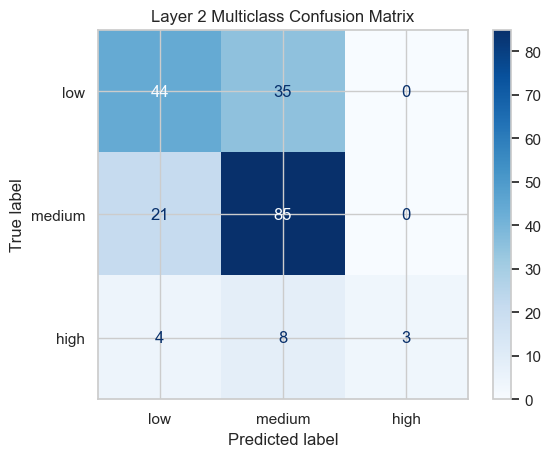

In [23]:
# Classifier 1: Multiclass (low/medium/high)
X = model_df[feature_cols].apply(pd.to_numeric, errors='coerce')
y_multi = model_df['poor_condition_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_multi, test_size=0.25, random_state=RANDOM_STATE, stratify=y_multi
)

rf_multi = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(
        n_estimators=700,
        random_state=RANDOM_STATE,
        class_weight='balanced_subsample',
        min_samples_leaf=2,
        n_jobs=-1,
    )),
])

rf_multi.fit(X_train, y_train)
pred_multi = rf_multi.predict(X_test)

print('Multiclass report (low/medium/high):')
print(classification_report(y_test, pred_multi, digits=3, zero_division=0))
print('Balanced accuracy:', round(balanced_accuracy_score(y_test, pred_multi), 4))

labels = ['low','medium','high']
cm = confusion_matrix(y_test, pred_multi, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues', values_format='d')
plt.title('Layer 2 Multiclass Confusion Matrix')
plt.show()


Binary report (high risk vs not): threshold=0.30
              precision    recall  f1-score   support

    not_high      0.932     0.892     0.912       185
        high      0.130     0.200     0.158        15

    accuracy                          0.840       200
   macro avg      0.531     0.546     0.535       200
weighted avg      0.872     0.840     0.855       200

Balanced accuracy: 0.5459


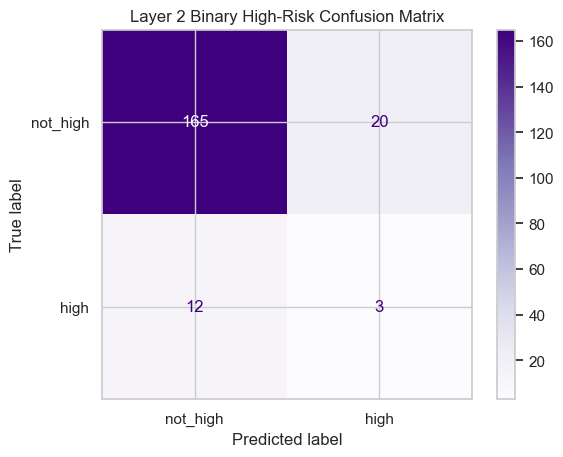

,importance
ndvi_slope_per_quarter,0.040193
bsi_2018_Q4,0.024861
ndvi_2021_Q2,0.017324
ndvi_2019_Q2,0.016953
ndvi_2019_Q3,0.015234
ndwi_2021_Q2,0.014593
ndwi_2019_Q3,0.014126
ndbi_2022_Q4,0.013534
ndvi_2018_Q1,0.013377
bsi_mean_2019,0.013047


In [24]:
# Classifier 2: Binary high-risk (high vs not_high)
Xb = model_df[feature_cols].apply(pd.to_numeric, errors='coerce')
yb = model_df['is_high_risk'].astype(int)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.25, random_state=RANDOM_STATE, stratify=yb
)

rf_bin = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(
        n_estimators=700,
        random_state=RANDOM_STATE,
        class_weight='balanced_subsample',
        min_samples_leaf=2,
        n_jobs=-1,
    )),
])

rf_bin.fit(Xb_train, yb_train)
proba = rf_bin.predict_proba(Xb_test)[:, 1]
pred = (proba >= 0.30).astype(int)  # screening-oriented threshold

print('Binary report (high risk vs not): threshold=0.30')
print(classification_report(yb_test, pred, target_names=['not_high','high'], digits=3, zero_division=0))
print('Balanced accuracy:', round(balanced_accuracy_score(yb_test, pred), 4))

cm = confusion_matrix(yb_test, pred, labels=[0,1])
ConfusionMatrixDisplay(cm, display_labels=['not_high','high']).plot(cmap='Purples', values_format='d')
plt.title('Layer 2 Binary High-Risk Confusion Matrix')
plt.show()

# feature importance snapshot
rfm = rf_bin.named_steps['rf']
imputer = rf_bin.named_steps['imputer']
rf_feature_names = imputer.get_feature_names_out(feature_cols)
imp = pd.Series(rfm.feature_importances_, index=rf_feature_names).sort_values(ascending=False)
display(imp.head(25).to_frame('importance'))


## Notes
- This rebuild uses new `progress_export.xlsx` labels (`low/medium/high`) and extends S2 features with 2017-2019 where available.
- If some 2017-2019 parquet files are unreadable in a given environment, the loader skips bad files and continues.
- For operations, the binary high-risk model can be treated as a screening layer (`high-risk` candidate list) rather than hard truth.
